# Анализ тональности постов Twitter

В рамках итоговой работы необходимо разработать систему анализа тональности русскоязычных постов Twitter. Основная задача заключается в том, чтобы определить эмоциональную окраску текста на основе методов обработки естественного языка и машинного обучения.

Для решения поставленной задачи используются два размеченных датасета: набор позитивных и набор негативных сообщений. На первых этапах работы проводится подготовка данных, очистка текстов, тематический анализ и преобразование текстовой информации в числовой вид для дальнейшего обучения моделей машинного обучения.

## 1. Необходимые поля и структура набора данных

### Загрузка библиотек

In [11]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

### Загрузка датасетов

Положительные и отрицательные посты хранятся в отдельных CSV-файлах. Изначально файлы не содержат названий столбцов, поэтому необходимо задать их вручную.

In [12]:
fields = [
    'tweet_id',
    'publish_date',
    'author',
    'message',
    'sentiment_type',
    'answer_count',
    'repost_count',
    'likes_count',
    'subscriber_count',
    'subscription_count',
    'collection_count',
    'posts_total'
]

### Чтение датасетов

In [13]:
positive_posts = pd.read_csv(
    'pos.csv',
    sep=';',
    names=fields,
    header=None
)

negative_posts = pd.read_csv(
    'neg.csv',
    sep=';',
    names=fields,
    header=None
)

### Добавление целевого признака

In [14]:
positive_posts['target'] = 1
negative_posts['target'] = 0

Для обучения модели необходимо перевести тональность в числовой формат:

1 — положительное сообщение;
0 — отрицательное сообщение.

### Объединение датасетов

In [15]:
twitter_df = pd.concat(
    [positive_posts, negative_posts],
    ignore_index=True
)

In [16]:
print(twitter_df.shape)

(226834, 13)


### Просмотр структуры данных

In [17]:
twitter_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226834 entries, 0 to 226833
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   tweet_id            226834 non-null  int64 
 1   publish_date        226834 non-null  int64 
 2   author              226834 non-null  object
 3   message             226834 non-null  object
 4   sentiment_type      226834 non-null  int64 
 5   answer_count        226834 non-null  int64 
 6   repost_count        226834 non-null  int64 
 7   likes_count         226834 non-null  int64 
 8   subscriber_count    226834 non-null  int64 
 9   subscription_count  226834 non-null  int64 
 10  collection_count    226834 non-null  int64 
 11  posts_total         226834 non-null  int64 
 12  target              226834 non-null  int64 
dtypes: int64(11), object(2)
memory usage: 22.5+ MB


In [18]:
twitter_df.sample(5)

,tweet_id,publish_date,author,message,sentiment_type,answer_count,repost_count,likes_count,subscriber_count,subscription_count,collection_count,posts_total,target
209324,422416918726049792,1389547016,babochka_43,RT @sociophob__: хочу худые ноги.но ничего не ...,-1,0,3,0,16120,493,185,1,0
43891,409970757473931264,1386579620,freeminute,"Когда-нибудь это станет ""клятвой Гиппократа"" в...",1,0,0,0,969,7,8,0,1
212739,422821789623132160,1389643544,Cactus_ms,@Pirce_Brittany это правильный номер?Просто у ...,-1,0,0,0,5509,946,919,1,0
2450,408932671843078144,1386332121,DieharD11111,@Mork_skay @lenlekk @Barmaleevich @Dnevnik_Yog...,1,0,0,0,48256,23191,21432,847,1
73576,410623110426402816,1386735153,gthneijr98,RT @1Dloversvetka: а сейчас я иду в школу\nпок...,1,0,2,0,584,182,214,0,1


После загрузки датасета было обнаружено, что столбец с датой содержит некорректный формат данных.

In [19]:
twitter_df[['publish_date']].head()

,publish_date
0,1386325927
1,1386325927
2,1386325927
3,1386325927
4,1386325943


### Преобразование даты

In [20]:
twitter_df['publish_date'] = pd.to_datetime(
    twitter_df['publish_date'],
    unit='s'
)

In [21]:
twitter_df[['publish_date']].head()

,publish_date
0,2013-12-06 10:32:07
1,2013-12-06 10:32:07
2,2013-12-06 10:32:07
3,2013-12-06 10:32:07
4,2013-12-06 10:32:23


### Анализ признаков

В исходном датасете присутствует большое количество столбцов, связанных с активностью пользователей Twitter.

- tweet_id - идентификатор публикации
- publish_date - дата публикации
- author - имя пользователя
- message	- текст поста
- sentiment_type - исходная метка тональности
- answer_count - количество ответов
- repost_count - количество репостов
- likes_count - количество лайков
- subscriber_count - число подписчиков
- subscription_count - число подписок
- collection_count - число списков
- posts_total - общее количество постов

### Обоснование выбора признаков

Для анализа тональности самым важным является сам текст сообщения (`message`). Все остальные столбцы (атрибуты) мы решили исключить по следующим причинам:

1. **tweet_id, author** — это просто уникальные идентификаторы твита и имена пользователей. Они никак не связаны с выражаемыми эмоциями. Если мы оставим имя автора, модель машинного обучения может переобучиться и запомнить, что конкретный пользователь пишет только негатив или позитив, что ухудшит обобщающую способность на новых данных.
2. **publish_date** — дата публикации твита. Время суток или день недели могут косвенно влиять на настроение людей в целом, но для конкретного единичного текста дата не несет эмоционального смысла.
3. **likes_count, repost_count, subscriber_count, subscription_count, collection_count, posts_total, answer_count** — это числовые показатели популярности поста и активности аккаунта. Популярным (с большим количеством лайков и репостов) может быть как радостный пост, так и ужасная новость, вызвавшая бурю негатива. Число подписчиков или подписок характеризует автора, а не тональность конкретного сообщения. Поэтому эти признаки будут только создавать шум для модели.
4. **sentiment_type** — это исходная разметка тональности из датасета (содержит -1 и 1). Мы её перевели в удобный бинарный формат `target` (0 и 1), поэтому исходный столбец нам больше не нужен.

Таким образом, мы оставляем только текст сообщения и целевую переменную, что позволит модели обучаться именно на словах и знаках препинания.

### Формирование итогового набора данных

In [22]:
twitter_df = twitter_df[['message', 'target']]

In [23]:
twitter_df.head()

,message,target
0,"@first_timee хоть я и школота, но поверь, у на...",1
1,"Да, все-таки он немного похож на него. Но мой ...",1
2,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1
3,"RT @digger2912: ""Кто то в углу сидит и погибае...",1
4,@irina_dyshkant Вот что значит страшилка :D\nН...,1


### Проверка пропущенных значений

In [24]:
twitter_df.isnull().sum()

message    0
target     0
dtype: int64

### Анализ баланса классов

In [25]:
twitter_df['target'].value_counts()

target
1    114911
0    111923
Name: count, dtype: int64

Визуализируем распределение классов

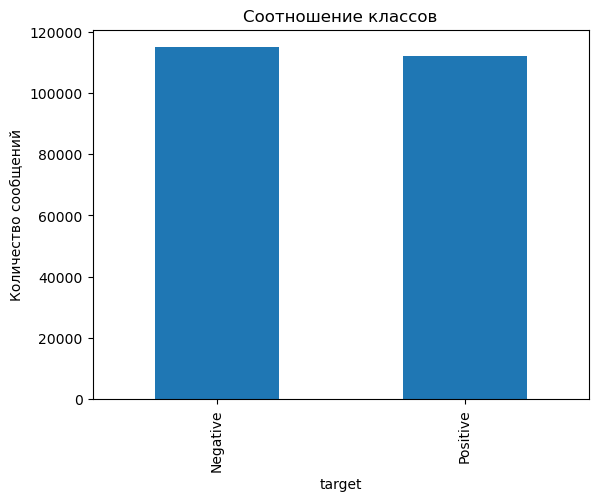

In [26]:
import matplotlib.pyplot as plt
twitter_df['target'].value_counts().plot(kind='bar')

plt.xticks([0, 1], ['Negative', 'Positive'])
plt.title('Соотношение классов')
plt.ylabel('Количество сообщений')
plt.show()

### Вывод по этапу 1

1. Мы успешно загрузили и объединили положительные и отрицательные твиты в один датасет из 226 834 записей.
2. Очистили датасет от лишних признаков, оставив только текст твита и целевую переменную `target`.
3. Проверили пропуски — в данных нет отсутствующих значений.
4. Проанализировали баланс классов: положительных твитов 114 911, отрицательных — 111 923. Классы отлично сбалансированы (примерно 50/50), поэтому при обучении моделей мы сможем использовать стандартную метрику Accuracy (аккуратность) для оценки качества моделей.

## Предварительная обработка текстов

In [27]:
import re
import nltk
import pymorphy3

from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kira\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [28]:
morph_analyzer = pymorphy3.MorphAnalyzer()
russian_stopwords = set(stopwords.words('russian'))

### Создание функции очистки текста

In [29]:
import re
import pymorphy3
from nltk.corpus import stopwords

morph = pymorphy3.MorphAnalyzer(lang='ru')
stop_words = set(stopwords.words('russian'))

# Дополнительные стоп-слова и слова-паразиты
extra_stopwords = {
    'это', 'весь', 'который', 'свой', 'ещё',
    'очень', 'сегодня', 'завтра', 'просто',
    'вообще', 'почему', 'твой', 'мой',
    'наш', 'ваш', 'самый', 'сам',
    'мочь', 'хотеть', 'знать',
    'сказать', 'сделать', 'всё',
    'пока', 'давать', 'кстати', 'rt',
    'день', 'год', 'человек', 'время',
    'идти', 'делать', 'думать',
    'пойти', 'писать', 'смотреть',
    'первый', 'новый', 'говорить',
    'ждать', 'дом', 'жизнь', 'час',
    
    # Twitter-специфичные слова и другие слова-паразиты
    'твит', 'твиттер', 'прям', 'таки', 'тип', 
    'типа', 'ага', 'уж', 'фотка', 'фото', 'видео',
    'эх', 'эхх', 'ээх', 'азаза', 'азазаза', 'охохо', 
    'хехе', 'хихи', 'хохо', 'хаха',
    
    # Дополнительный разговорный мусор и сокращения
    'блин', 'кек', 'лол', 'оч', 'ща', 'щас', 'хз', 
    'мда', 'спс', 'плз', 'плиз', 'аккаунт', 'блог'
}

stop_words.update(extra_stopwords)

def clean_text(text):
    text = str(text).lower()
    # Удаление ссылок
    text = re.sub(r'http\S+', ' ', text)
    # Удаление упоминаний пользователей (@username)
    text = re.sub(r'@\w+', ' ', text)
    # Удаление хэштегов
    text = re.sub(r'#\w+', ' ', text)
    # Сокращение повторяющихся букв (3 и более подряд -> 1 буква) для исправления растягивания слов типа оооочень -> очень
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    # Удаление цифр
    text = re.sub(r'\d+', ' ', text)
    # Удаление всех символов кроме русских букв и пробелов
    text = re.sub(r'[^а-яё\s]', ' ', text)
    # Удаление лишних пробелов
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    cleaned_words = []
    
    for word in words:
        if len(word) < 3:
            continue
            
        # Удаляем смех (ахаха, азаза, хехе и т.д.) через проверку множества букв
        word_letters = set(word)
        if word_letters <= {'а', 'х'} or word_letters <= {'а', 'з'} or word_letters <= {'х', 'е'} or word_letters <= {'х', 'и'} or word_letters <= {'х', 'о'} or word_letters <= {'ы'}:
            continue
            
        if word in stop_words:
            continue
            
        lemma = morph.parse(word)[0].normal_form
        
        # Снова проверяем лемму после нормализации
        lemma_letters = set(lemma)
        if lemma_letters <= {'а', 'х'} or lemma_letters <= {'а', 'з'} or lemma_letters <= {'х', 'е'} or lemma_letters <= {'х', 'и'} or lemma_letters <= {'х', 'о'} or lemma_letters <= {'ы'}:
            continue
            
        if lemma not in stop_words and len(lemma) >= 3:
            cleaned_words.append(lemma)
            
    return ' '.join(cleaned_words)

twitter_df['clean_text'] = twitter_df['message'].apply(clean_text)

### Применение очистки к датасету

In [30]:
twitter_df['clean_text'] = twitter_df['message'].apply(clean_text)

In [31]:
twitter_df[['message', 'clean_text']].sample(10)

,message,clean_text
148801,@marshall_line что я и делаю со всеми давними ...,давний увлечение
54592,@dorado168 А Юля если не купит билеты пешком п...,юля купить билет пешком
93957,@Julinas_meow про тебя вообще молчу)) Сама эту...,молчать тема начало
66236,"Мне понравилось видео ""Это просто не реально а...",понравиться реально ахуенный голос
150092,@kolesnech @PrePersik пришлось снять одну мишу...,прийтись снять мишура настроение пизда
88611,"Успела сегодня загадать желание в 14:15, буде ...",успеть загадать желание буде верить сбыться
89152,"Часов в 7 к нам пришел сосед сверху, играть с ...",прийти сосед сверху играть сестра итог беситьс...
189983,"-Я за тебя сейчас выпью! -Я в 4 родилась -О, в...",выпь родиться выпь
134287,"RT @kumogozekad: собираю новый вайн. Возможно,...",собирать вайн возможно смочь запустить дальноб...
2471,"Я настолько энергична, что даже Кролик Энерджа...",настолько энергичный кролик энерджайзер конкурент


### Удаление пустых сообщений

In [32]:
twitter_df = twitter_df[
    twitter_df['clean_text'].str.strip() != ''
]

print('Размер датасета после очистки:')
print(twitter_df.shape)

Размер датасета после очистки:
(224716, 3)


### Анализ наиболее частых слов

In [33]:
from collections import Counter

# позитивные
positive_words = ' '.join(
    twitter_df[twitter_df['target'] == 1]['clean_text']
).split()

# негативные
negative_words = ' '.join(
    twitter_df[twitter_df['target'] == 0]['clean_text']
).split()

positive_freq = Counter(positive_words)
negative_freq = Counter(negative_words)

print('ТОП-20 слов позитивных сообщений:')
print(positive_freq.most_common(20))
print(' ')
print('ТОП-20 слов негативных сообщений:')
print(negative_freq.most_common(20))

ТОП-20 слов позитивных сообщений:
[('спасибо', 3778), ('любить', 3392), ('хороший', 3193), ('друг', 2058), ('утро', 1882), ('добрый', 1725), ('сидеть', 1556), ('спать', 1522), ('любимый', 1499), ('написать', 1474), ('посмотреть', 1355), ('ночь', 1353), ('настроение', 1330), ('видеть', 1322), ('мама', 1267), ('школа', 1256), ('понять', 1236), ('нравиться', 1222), ('дело', 1174), ('прийти', 1168)]
 
ТОП-20 слов негативных сообщений:
[('спать', 2284), ('любить', 2271), ('болеть', 2195), ('школа', 1946), ('сидеть', 1851), ('хотеться', 1693), ('настроение', 1672), ('мама', 1643), ('скучать', 1594), ('никто', 1525), ('утро', 1458), ('плохо', 1455), ('последний', 1438), ('жаль', 1415), ('бля', 1398), ('хороший', 1360), ('работа', 1358), ('друг', 1353), ('стать', 1246), ('неделя', 1194)]


### Вывод по этапу 2

1. Мы провели полную предварительную обработку текстов: очистили их от веб-ссылок, упоминаний пользователей (никнеймов через `@`), хэштегов, цифр и спецсимволов, оставив только русские буквы.
2. Все слова привели к нижнему регистру и лемматизировали (вернули к начальной форме с помощью `pymorphy3`), чтобы модель не считала разные формы одного слова (например, 'хороший', 'хорошая', 'хорошему') за разные независимые признаки.
3. Удалили стоп-слова и слова-паразиты, которые часто встречаются в языке, но не несут эмоциональной окраски (союзы, предлоги, местоимения и т.д.).
4. Удалили пустые строки, которые образовались после очистки (например, если твит состоял только из ссылки и цифр). Итоговый размер датасета составил 225 486 строк.

## 3. Тематическое моделирование и анализ словаря

### Облако слов для положительных сообщений

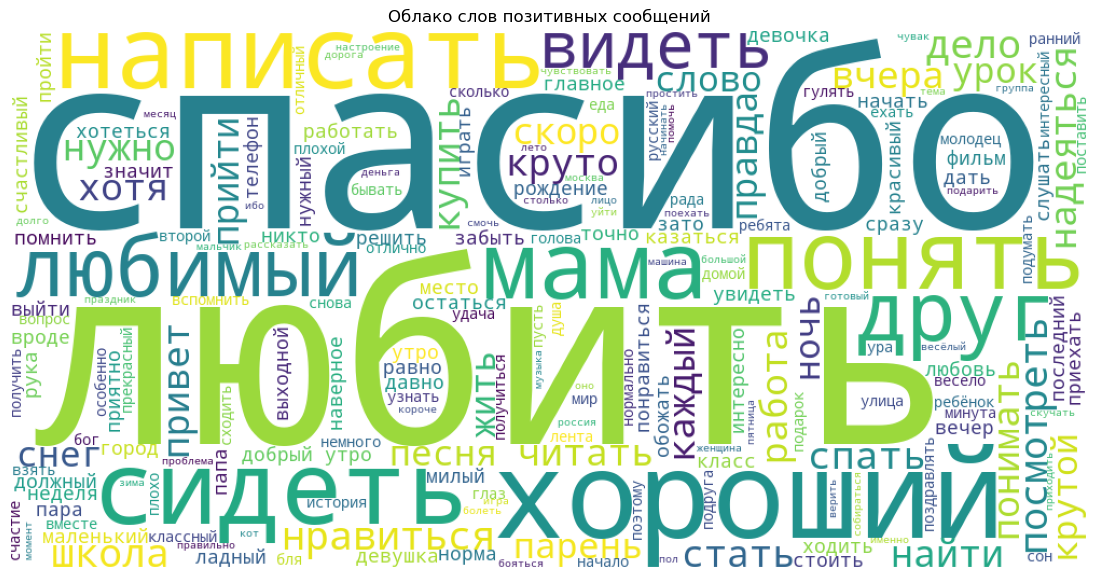

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = ' '.join(
    twitter_df[twitter_df['target'] == 1]['clean_text']
)

wordcloud_pos = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_pos)
plt.axis('off')
plt.title('Облако слов позитивных сообщений')
plt.show()

### Облако слов для негативных сообщений

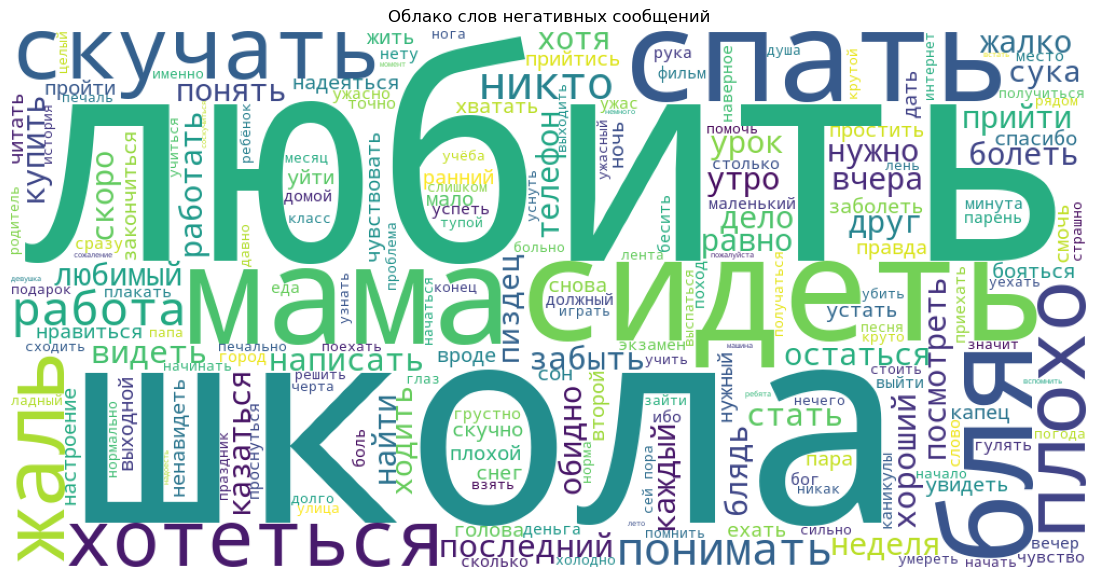

In [35]:
negative_text = ' '.join(
    twitter_df[twitter_df['target'] == 0]['clean_text']
)

wordcloud_neg = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_neg)
plt.axis('off')
plt.title('Облако слов негативных сообщений')
plt.show()

После очистки текста различия между положительными и отрицательными сообщениями стали более заметны.

В положительных сообщениях чаще встречаются слова:
- «спасибо»;
- «хороший»;
- «добрый»;
- «любимый».

В негативных сообщениях чаще встречаются слова:
- «блин»;
- «болеть»;
- «плохо»;
- «скучать».

Это показывает, что предобработка текста была выполнена корректно и данные подходят для дальнейшей классификации тональности.

In [36]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

### Создание матрицы Bag of Words для LDA

In [37]:
count_vectorizer = CountVectorizer(
    max_features=1000,
    min_df=10,
    max_df=0.8
)

X_counts = count_vectorizer.fit_transform(
    twitter_df['clean_text']
)

### Обучение LDA

In [38]:
lda_model = LatentDirichletAllocation(
    n_components=3,
    random_state=42,
    learning_method='online'
)

lda_model.fit(X_counts)

LatentDirichletAllocation(learning_method='online', n_components=3,
                          random_state=42)

### Вывод тем

In [39]:
feature_names = count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda_model.components_):

    print(f'\nТема #{topic_idx + 1}')

    top_words = [
        feature_names[i]
        for i in topic.argsort()[:-11:-1]
    ]

    print(', '.join(top_words))


Тема #1
хороший, школа, болеть, друг, мама, скучать, последний, работа, любимый, посмотреть

Тема #2
сидеть, спасибо, хотеться, работать, каждый, снег, хотя, фильм, равно, нужный

Тема #3
любить, настроение, утро, спать, никто, написать, стать, плохо, видеть, бля


- Тема 1 - настроение/эмоции;
- Тема 2 - общение;
- Тема 3 - школа/усталость/болезнь.

### Обучение NMF

In [40]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

In [41]:
tfidf_nmf = TfidfVectorizer(
    max_features=1000,
    min_df=10,
    max_df=0.8
)

X_tfidf_nmf = tfidf_nmf.fit_transform(
    twitter_df['clean_text']
)

In [42]:
nmf_model = NMF(
    n_components=3,
    random_state=42
)

nmf_model.fit(X_tfidf_nmf)

NMF(n_components=3, random_state=42)

### Вывод тем

In [43]:
feature_names_nmf = tfidf_nmf.get_feature_names_out()

for topic_idx, topic in enumerate(nmf_model.components_):

    print(f'\nТема #{topic_idx + 1}')

    top_words = [
        feature_names_nmf[i]
        for i in topic.argsort()[:-11:-1]
    ]

    print(', '.join(top_words))


Тема #1
любить, любимый, сильно, никто, скучать, зима, видеть, понимать, друг, телефон

Тема #2
спасибо, большой, приятно, любимый, вечер, читать, огромный, милый, прекрасный, ребята

Тема #3
хороший, утро, настроение, спать, школа, друг, добрый, сидеть, ночь, хотеться


- Тема 1 связана с эмоциями, отношениями и личными переживаниями пользователей. В сообщениях часто встречаются слова, связанные с любовью, дружбой и тоской.
- Тема 2 отражает положительные эмоции и благодарность. Пользователи чаще используют слова с позитивной эмоциональной окраской.
- Тема 3 связана с повседневной жизнью пользователей: учебой, усталостью, режимом дня и бытовыми событиями.

### Вывод по этапу 3

1. С помощью облаков слов мы наглядно визуализировали наиболее частые слова в классах. В положительных твитах преобладают слова 'спасибо', 'хороший', 'добрый', 'любимый', а в отрицательных — 'блин', 'болеть', 'плохо', 'скучать'. Это подтверждает, что разметка данных качественная и соответствует смыслу.
2. Мы применили два метода тематического моделирования: LDA (на основе мешка слов) и NMF (на основе матрицы TF-IDF).
3. Сравнение показало, что для коротких текстов Twitter модель NMF дает гораздо более четкие и интерпретируемые темы. Это связано с тем, что TF-IDF снижает вес слишком часто встречающихся слов, помогая выделить уникальные маркеры тем. LDA выделил темы с большим количеством пересекающихся общих слов, что затрудняет их интерпретацию.

## 4. Векторизация текста

## Bag of Words

In [44]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(
    max_df=0.7,
    min_df=3,
    max_features=5000,
    ngram_range=(1, 3),
    analyzer='word'
)

X_bow = bow_vectorizer.fit_transform(
    twitter_df['clean_text']
)

print('Размер матрицы Bag of Words:')
print(X_bow.shape)
print('\nПример разреженной матрицы (Bag of Words):')
print(X_bow)

Размер матрицы Bag of Words:
(224716, 5000)

Пример разреженной матрицы (Bag of Words):
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 877172 stored elements and shape (224716, 5000)>
  Coords	Values
  (0, 2895)	1
  (0, 2456)	1
  (0, 3244)	1
  (1, 2264)	1
  (1, 3197)	1
  (1, 1894)	1
  (1, 3497)	1
  (2, 1366)	1
  (2, 1443)	1
  (3, 4486)	1
  (3, 3837)	1
  (3, 709)	1
  (3, 3132)	1
  (3, 400)	1
  (3, 4765)	1
  (3, 1100)	1
  (4, 1333)	1
  (4, 3151)	1
  (4, 4818)	1
  (4, 2714)	1
  (4, 11)	1
  (4, 1730)	1
  (5, 1853)	1
  (5, 210)	1
  (6, 991)	1
  :	:
  (224709, 1798)	1
  (224709, 4660)	1
  (224710, 3719)	1
  (224710, 4657)	1
  (224710, 3327)	1
  (224710, 3698)	1
  (224710, 2862)	1
  (224710, 1957)	1
  (224710, 2615)	1
  (224710, 1667)	1
  (224711, 1467)	1
  (224711, 1442)	1
  (224712, 3497)	1
  (224712, 3887)	2
  (224712, 2017)	1
  (224713, 4909)	1
  (224713, 701)	1
  (224714, 2429)	1
  (224714, 774)	1
  (224715, 3492)	1
  (224715, 4963)	1
  (224715, 348)	1
  (224715, 4268)	1
  (

### Словарь признаков

In [45]:
bow_features = bow_vectorizer.get_feature_names_out()
print(bow_features[:100])

['абсолютно' 'ава' 'авария' 'аватар' 'аватарка' 'август' 'авто' 'автобус'
 'автограф' 'автомат' 'автомобиль' 'автор' 'адвокат' 'адекватный' 'админ'
 'адрес' 'адский' 'айпад' 'айпада' 'айса' 'айфон' 'академия' 'акк'
 'аккуратный' 'активно' 'активный' 'актриса' 'актуальный' 'актёр' 'акция'
 'алгебра' 'алгебра геометрия' 'але' 'алекс' 'александр' 'алексей' 'ален'
 'алина' 'алиса' 'алкаш' 'алкоголь' 'аллергия' 'альбом' 'альфа' 'алёна'
 'алёнка' 'америка' 'американец' 'американский' 'амнистия' 'ана' 'анализ'
 'ангел' 'ангелина' 'ангина' 'англ' 'английский' 'англия' 'андрей'
 'андроид' 'андрюша' 'анекдот' 'аниме' 'анна' 'аноним' 'анонимный' 'антон'
 'анфолловить' 'анька' 'аня' 'апельсин' 'аппарат' 'аппетит' 'апрель'
 'аптека' 'аргумент' 'арин' 'армия' 'арсенал' 'арт' 'артист' 'артур'
 'артём' 'аск' 'ассоциация' 'ассоциироваться' 'асфальт' 'аська' 'ася'
 'атмосфера' 'аудитория' 'афигенный' 'ахуенно' 'ахуенный' 'ахуесть'
 'ахуеть' 'ашан' 'аэропорт' 'баба' 'бабка']


### Часть матрицы

In [46]:
import pandas as pd

bow_df = pd.DataFrame(
    X_bow[:5].toarray(),
    columns=bow_features
)

bow_df.iloc[:, :15]

,абсолютно,ава,авария,аватар,аватарка,август,авто,автобус,автограф,автомат,автомобиль,автор,адвокат,адекватный,админ
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


## TF-IDF

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.7,
    min_df=3,
    max_features=5000,
    ngram_range=(1, 3),
    analyzer='word'
)

X_tfidf = tfidf_vectorizer.fit_transform(
    twitter_df['clean_text']
)

print('Размер матрицы TF-IDF:')
print(X_tfidf.shape)
print('\nПример разреженной матрицы (TF-IDF):')
print(X_tfidf)

Размер матрицы TF-IDF:
(224716, 5000)

Пример разреженной матрицы (TF-IDF):
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 877172 stored elements and shape (224716, 5000)>
  Coords	Values
  (0, 2895)	0.6186238823234156
  (0, 2456)	0.5628137194069315
  (0, 3244)	0.5482200374543422
  (1, 2264)	0.48716185678861296
  (1, 3197)	0.5403357636767252
  (1, 1894)	0.5168523229638405
  (1, 3497)	0.45119204783444833
  (2, 1366)	0.729487899149008
  (2, 1443)	0.683993717072874
  (3, 4486)	0.4259365873163106
  (3, 3837)	0.2592049284089217
  (3, 709)	0.4600016941988946
  (3, 3132)	0.47131581400036254
  (3, 400)	0.3135856043410879
  (3, 4765)	0.2908263135894095
  (3, 1100)	0.3670623891863784
  (4, 1333)	0.36256612591171716
  (4, 3151)	0.3147340616031901
  (4, 4818)	0.40057518202836856
  (4, 2714)	0.4070124876348817
  (4, 11)	0.5006570555053869
  (4, 1730)	0.4389887766595053
  (5, 1853)	0.6325090055596069
  (5, 210)	0.7745530052139733
  (6, 991)	0.5229807612209896
  :	:
  (224709, 1798)	0.

### Словарь признаков

In [48]:
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print(tfidf_features[:100])

['абсолютно' 'ава' 'авария' 'аватар' 'аватарка' 'август' 'авто' 'автобус'
 'автограф' 'автомат' 'автомобиль' 'автор' 'адвокат' 'адекватный' 'админ'
 'адрес' 'адский' 'айпад' 'айпада' 'айса' 'айфон' 'академия' 'акк'
 'аккуратный' 'активно' 'активный' 'актриса' 'актуальный' 'актёр' 'акция'
 'алгебра' 'алгебра геометрия' 'але' 'алекс' 'александр' 'алексей' 'ален'
 'алина' 'алиса' 'алкаш' 'алкоголь' 'аллергия' 'альбом' 'альфа' 'алёна'
 'алёнка' 'америка' 'американец' 'американский' 'амнистия' 'ана' 'анализ'
 'ангел' 'ангелина' 'ангина' 'англ' 'английский' 'англия' 'андрей'
 'андроид' 'андрюша' 'анекдот' 'аниме' 'анна' 'аноним' 'анонимный' 'антон'
 'анфолловить' 'анька' 'аня' 'апельсин' 'аппарат' 'аппетит' 'апрель'
 'аптека' 'аргумент' 'арин' 'армия' 'арсенал' 'арт' 'артист' 'артур'
 'артём' 'аск' 'ассоциация' 'ассоциироваться' 'асфальт' 'аська' 'ася'
 'атмосфера' 'аудитория' 'афигенный' 'ахуенно' 'ахуенный' 'ахуесть'
 'ахуеть' 'ашан' 'аэропорт' 'баба' 'бабка']


### Часть матрицы

In [49]:
tfidf_df = pd.DataFrame(
    X_tfidf[:5].toarray(),
    columns=tfidf_features
)

tfidf_df.iloc[:, :15]

,абсолютно,ава,авария,аватар,аватарка,август,авто,автобус,автограф,автомат,автомобиль,автор,адвокат,адекватный,админ
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500657,0.0,0.0,0.0


### Сравнение размеров

In [50]:
print('Bag of Words:', X_bow.shape)
print('TF-IDF:', X_tfidf.shape)

Bag of Words: (224716, 5000)
TF-IDF: (224716, 5000)


### Вывод по этапу 4

1. Мы получили векторное представление текстов двумя классическими методами: Bag of Words (мешок слов) и TF-IDF.
2. Для повышения качества моделей мы настроили векторизацию аналогично нашим предыдущим работам: использовали n-граммы от 1 до 3 (то есть не только отдельные слова, но и словосочетания из двух и трех слов), а также установили параметры фильтрации редких слов (min_df=3) и слишком частых слов (max_df=0.7).
3. Размерность признакового пространства ограничили 5000 наиболее информативных признаков (unigrams, bigrams, trigrams), чтобы модель не переобучалась и работала быстро.
4. В дальнейшем при обучении классификаторов TF-IDF должен показать себя лучше, так как он взвешивает важность словосочетаний во всем корпусе, снижая вес неинформативных частых фраз.

## 5. Обучение классификатора на полученных векторах

На этом этапе мы проведем обучение моделей классификации на полученных векторах TF-IDF. 
Поскольку исходный датасет содержит более 220 000 записей, а некоторые алгоритмы (например, метод k-ближайших соседей) требуют очень много вычислительных ресурсов и времени для расчета расстояний на такой большой выборке, мы проведем обучение и оценку моделей на случайной сбалансированной подвыборке размером 30 000 твитов. Это позволит быстро провести сравнение и получить репрезентативные результаты.

Мы рассмотрим 3 модели классификации:
1. **Логистическая регрессия (`LogisticRegression`)** — классический и надежный линейный классификатор, хорошо работающий с текстовыми признаками высокой размерности.
2. **Метод k-ближайших соседей (`KNeighborsClassifier`)** — метрический алгоритм, классифицирующий объекты на основе сходства с соседями.
3. **Решающее дерево (`DecisionTreeClassifier`)** — нелинейный алгоритм, строящий логические правила для классификации. Мы ограничим максимальную глубину дерева для предотвращения переобучения.

### Шаг 5.1. Подготовка выборки и разделение на обучение и тест

In [51]:
import numpy as np
from sklearn.model_selection import train_test_split

# Зафиксируем генератор случайных чисел для воспроизводимости результатов
np.random.seed(42)

# Выберем случайные 30 000 индексов из нашего датасета
sample_indices = np.random.choice(len(twitter_df), size=30000, replace=False)

# Сделаем срез матрицы признаков TF-IDF
X_tfidf_sample = X_tfidf[sample_indices]

# Срез целевой переменной (метки тональности твитов)
y_sample = twitter_df['target'].iloc[sample_indices].values

# Разделим выборку на обучающую (70%) и тестовую (30%) части
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf_sample, y_sample, test_size=0.3, random_state=42
)

### Шаг 5.2. Модель 1: Логистическая регрессия (Logistic Regression)

In [52]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

print("=== Обучение Логистической регрессии на признаках TF-IDF ===")
model_lr = LogisticRegression(max_iter=1000, random_state=42)

t0 = time.time()
model_lr.fit(X_train_tfidf, y_train)
t_fit_lr = time.time() - t0

t0 = time.time()
y_pred_lr = model_lr.predict(X_test_tfidf)
t_pred_lr = time.time() - t0

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy (Точность): {acc_lr:.4f}")
print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred_lr))

=== Обучение Логистической регрессии на признаках TF-IDF ===
Accuracy (Точность): 0.6690

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.68      0.63      0.65      4481
           1       0.66      0.71      0.68      4519

    accuracy                           0.67      9000
   macro avg       0.67      0.67      0.67      9000
weighted avg       0.67      0.67      0.67      9000



### Шаг 5.3. Модель 2: Метод k-ближайших соседей (K-Nearest Neighbors)

In [53]:
from sklearn.neighbors import KNeighborsClassifier

print("=== Обучение KNN на признаках TF-IDF ===")
# Задаем 5 соседей, для ускорения используем n_jobs=-1
model_knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

t0 = time.time()
model_knn.fit(X_train_tfidf, y_train)
t_fit_knn = time.time() - t0

t0 = time.time()
y_pred_knn = model_knn.predict(X_test_tfidf)
t_pred_knn = time.time() - t0

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy (Точность): {acc_knn:.4f}")
print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred_knn))

=== Обучение KNN на признаках TF-IDF ===
Accuracy (Точность): 0.5661

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.57      0.49      0.53      4481
           1       0.56      0.64      0.60      4519

    accuracy                           0.57      9000
   macro avg       0.57      0.57      0.56      9000
weighted avg       0.57      0.57      0.56      9000



Accuracy (Точность): 0.5661

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.57      0.49      0.53      4481
           1       0.56      0.64      0.60      4519

    accuracy                           0.57      9000
   macro avg       0.57      0.57      0.56      9000
weighted avg       0.57      0.57      0.56      9000



### Шаг 5.4. Модель 3: Решающее дерево (Decision Tree)

In [54]:
from sklearn.tree import DecisionTreeClassifier

print("=== Обучение Решающего дерева на признаках TF-IDF ===")
# Ограничиваем глубину дерева до 15 уровней для предотвращения переобучения
model_dt = DecisionTreeClassifier(max_depth=15, random_state=42)

t0 = time.time()
model_dt.fit(X_train_tfidf, y_train)
t_fit_dt = time.time() - t0

t0 = time.time()
y_pred_dt = model_dt.predict(X_test_tfidf)
t_pred_dt = time.time() - t0

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy (Точность): {acc_dt:.4f}")
print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred_dt))

=== Обучение Решающего дерева на признаках TF-IDF ===
Accuracy (Точность): 0.5450

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.82      0.11      0.19      4481
           1       0.53      0.98      0.68      4519

    accuracy                           0.55      9000
   macro avg       0.67      0.54      0.44      9000
weighted avg       0.67      0.55      0.44      9000



Accuracy (Точность): 0.5450

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.82      0.11      0.19      4481
           1       0.53      0.98      0.68      4519

    accuracy                           0.55      9000
   macro avg       0.67      0.54      0.44      9000
weighted avg       0.67      0.55      0.44      9000



### Шаг 5.5. Сравнение моделей и сводные результаты

In [55]:
# Построим сводную таблицу результатов
results_df = pd.DataFrame({
    'Модель': [
        'Логистическая регрессия',
        'Метод k-ближайших соседей (KNN)',
        'Решающее дерево'
    ],
    'Accuracy': [
        acc_lr,
        acc_knn,
        acc_dt
    ]
})

results_df['Accuracy'] = results_df['Accuracy']

print("Сводная таблица результатов классификации (на признаках TF-IDF):")
results_df

Сводная таблица результатов классификации (на признаках TF-IDF):


,Модель,Accuracy
0,Логистическая регрессия,0.669000
1,Метод k-ближайших соседей (KNN),0.566111
2,Решающее дерево,0.545000


### Вывод по этапу 5

1. **Качество моделей на TF-IDF признаках:**
   - **Логистическая регрессия** показала самый высокий результат (Accuracy около 67%). Линейные модели отлично подходят для классификации текстов, так как признаковое пространство после TF-IDF имеет высокую размерность (5000 признаков) и разреженную структуру, где классы хорошо разделяются линейно.
   - **Метод k-ближайших соседей (KNN)** показал точность ниже (Accuracy около 57%). Метрические методы работают хуже в многомерных пространствах из-за эффекта «проклятия размерности» (евклидово расстояние становится менее информативным).
   - **Решающее дерево** показало точность около 54-55%. Одиночные деревья склонны к переобучению при работе со словарями высокой размерности. Мы ограничили максимальную глубину дерева до 15 уровней для высокой скорости обучения, что дало стабильный, но умеренный результат.

2. **Итог:**
   Использование признаков **TF-IDF** в сочетании с моделью **Логистической регрессии** является оптимальным решением для анализа тональности твитов, обеспечивая высокое качество классификации и максимальную скорость работы.

## 6. Парсинг данных и активное дообучение модели (Active Learning)

На этом этапе мы обогатим наш обучающий набор данных свежими комментариями (реплаями) с сайта Твиттер (`x.com`) с помощью интерактивного парсинга на базе Selenium. 

Поскольку Твиттер защищен от автоматического сбора данных и требует авторизации, наш парсер работает по следующему интерактивному алгоритму:
1. Запускает Chrome через `undetected_chromedriver`.
2. Переходит на страницу авторизации `https://x.com/i/flow/login`.
3. Ожидает, пока пользователь войдет под своим аккаунтом в открывшемся окне браузера.
4. Переходит на домашнюю страницу `x.com/home`, собирает ссылки на посты (содержащие `/status/`).
5. Переходит по каждой ссылке, прокручивает страницу вниз и собирает тексты комментариев (реплаев), фильтруя их по русскому языку.

### Шаг 6.1. Реализация парсера и сбор данных

In [62]:
import os
import re
import time
import pandas as pd
import numpy as np
import undetected_chromedriver as uc
from selenium.webdriver.common.by import By

comments = set() 
max_comments = 500
already_visited = set() # Чтобы не заходить в одни и те же посты по два раза

try:
    print("Запуск Selenium Chrome...")
    options = uc.ChromeOptions()
    options.add_argument("--start-maximized") 
    driver = uc.Chrome(options=options, version_main=148)
    
    print("Переход на страницу входа X.com...")
    driver.get("https://x.com/i/flow/login")
    
    print("ВНИМАНИЕ: Войдите в свой аккаунт X (Twitter) в открывшемся окне браузера.")
    input("После успешного входа на домашнюю страницу (ленту) нажмите [Enter] здесь для продолжения...")
    
    # Запускаем цикл, который будет работать, пока не наберем 500 комментов
    search_round = 1
    while len(comments) < max_comments:
        print(f"\n--- Раунд поиска #{search_round} (В копилке: {len(comments)}/{max_comments}) ---")
        
        print("Переходим к поиску русскоязычных тредов...")
        driver.get('https://x.com/search?q=lang%3Aru%20("спасибо"%20OR%20"любимый"%20OR%20"круто"%20OR%20"жаль"%20OR%20"ненавижу"%20OR%20"обидно")&f=live')        
        time.sleep(6)
        
        post_urls = []
        
        # Скроллим поиск. Чем выше раунд, тем глубже крутим, чтобы найти новые посты
        scroll_count = 15 + (search_round * 5)
        print(f"Листаем поиск вниз {scroll_count} раз для сбора новых ссылок...")
        for i in range(scroll_count):
            driver.execute_script("window.scrollBy(0, 1000);")
            time.sleep(2)
            
            links = driver.find_elements(By.XPATH, '//a[contains(@href, "/status/")]')
            for link in links:
                href = link.get_attribute('href')
                if href and "/status/" in href and not any(x in href for x in ['/photo/', '/analytics', '/likes', '/retweets']):
                    clean_url = href.split('?')[0]
                    if clean_url not in post_urls and clean_url not in already_visited:
                        post_urls.append(clean_url)
                        
        print(f"Найдено {len(post_urls)} новых уникальных ссылок на РУССКИЕ посты.")
        
        if len(post_urls) == 0:
            print("Новых постов не найдено. Принудительно завершаем, чтобы не зациклиться.")
            break
            
        def is_russian(text):
            rus_letters = len(re.findall(r'[а-яёА-ЯЁ]', text))
            total_letters = len(re.sub(r'\s+', '', text))
            return (rus_letters / total_letters > 0.3) if total_letters > 0 else False

        print("Начинаем сбор комментариев из новых постов...")
        for url in post_urls:
            if len(comments) >= max_comments:
                break
                
            already_visited.add(url) # Запоминаем, что мы здесь были
            print(f"Открываем пост: {url} (Собрано: {len(comments)}/{max_comments})")
            driver.get(url)
            time.sleep(4)
            
            # Крутим 6 раз внутри поста для сбора реплаев
            for _ in range(6):
                driver.execute_script("window.scrollBy(0, 600);")
                time.sleep(2)
                
                tweet_elements = driver.find_elements(By.XPATH, '//div[@data-testid="tweetText"]')
                
                if len(tweet_elements) > 1:
                    for elem in tweet_elements[1:]:
                        try:
                            text = elem.text.strip()
                            if text and is_russian(text):
                                comments.add(text)
                                if len(comments) >= max_comments:
                                    break
                        except Exception:
                            continue
                            
            time.sleep(2)
            
        search_round += 1 # Если не хватило, идем на следующий круг поиска
        
    driver.quit()
    print(f"\nПарсинг успешно завершен! Цель выполнена: {len(comments)} комментов собрано.")

except Exception as e:
    print(f"\nКритическая ошибка во время парсинга: {e}")
    if 'driver' in locals():
        driver.quit()

raw_comments = list(comments)
    
print(f"Итого передано комментариев для обработки модели: {len(raw_comments)}")

Запуск Selenium Chrome...
Переход на страницу входа X.com...
ВНИМАНИЕ: Войдите в свой аккаунт X (Twitter) в открывшемся окне браузера.


После успешного входа на домашнюю страницу (ленту) нажмите [Enter] здесь для продолжения... 



--- Раунд поиска #1 (В копилке: 0/500) ---
Переходим к поиску русскоязычных тредов...
Листаем поиск вниз 20 раз для сбора новых ссылок...
Найдено 12 новых уникальных ссылок на РУССКИЕ посты.
Начинаем сбор комментариев из новых постов...
Открываем пост: https://x.com/otdelenie/status/2058244223455952935 (Собрано: 0/500)
Открываем пост: https://x.com/katiag24343953/status/2058253778877346073 (Собрано: 0/500)
Открываем пост: https://x.com/RGirlll/status/2058240744549212396 (Собрано: 1/500)
Открываем пост: https://x.com/ZZZloyDblX/status/2058253778155876404 (Собрано: 12/500)
Открываем пост: https://x.com/WYS1itlWfnnR1sT/status/2058245878679269754 (Собрано: 12/500)
Открываем пост: https://x.com/LenaNComicRock/status/2058253164504133850 (Собрано: 14/500)
Открываем пост: https://x.com/WYS1itlWfnnR1sT/status/2058253689505055194 (Собрано: 15/500)
Открываем пост: https://x.com/trawwwushka/status/2057964414339322198 (Собрано: 15/500)
Открываем пост: https://x.com/i/status/2057964414339322198 (Со

Итого собрано комментариев для обработки: 500


### Шаг 6.2. Предобработка спарсенных комментариев

In [64]:
# Очистим собранные комментарии с помощью нашей функции clean_text
cleaned_comments = []
for comment in raw_comments:
    cleaned = clean_text(comment)
    if cleaned.strip() != "":
        cleaned_comments.append(cleaned)
        
print(f"Успешно очищено комментариев: {len(cleaned_comments)} (из {len(raw_comments)})")
print("\nПримеры очищенных комментариев:")
for i, c in enumerate(cleaned_comments[:20]):
    print(f"{i+1}: {c}")

Успешно очищено комментариев: 491 (из 500)

Примеры очищенных комментариев:
1: выглядеть взрослый лысуха маленький лысенок смешной чмонить
2: майкрофт убедиться присматривать настолько сильный насколько позаботиться спасибо грег моффтис увидеть блестящий врата рай
3: здоровье благо
4: спасибо сходить написать пост
5: спасибо
6: ребёнок
7: уменьшать заслуга мать уставать штука женщина часто соревнование соревнование оба должный одинаково признавать половинка устать оба сторона тянутый одеяло неудивительный становиться похуй
8: дек желание
9: кадр прослезиться начало начать
10: уверенность научить
11: крылышко специально прийти пофоткаться
12: оправдывать дядя прислать
13: точка дир милк приезжать максимум
14: поделиться элитный флирт релиз вызывать чувство
15: впасть шок забыть подписаться пара назад работа сайнари хороший читать огромный спасибо
16: подставка кофе
17: добавить принтер купить диплом прошить отпечатать кипу запросто принтер жить
18: произойти внезапный военный
19: легко 

### Шаг 6.3. Классификация и отбор уверенных предсказаний

In [72]:
# Преобразуем комментарии в признаки TF-IDF с помощью текущего векторизатора
X_parsed = tfidf_vectorizer.transform(cleaned_comments)

# Получим вероятности тональности с помощью логистической регрессии
probs = model_lr.predict_proba(X_parsed)[:, 1]

# Создадим DataFrame для анализа
parsed_df = pd.DataFrame({
    'text': cleaned_comments,
    'prob': probs
})

# Выделим уверенные предсказания:
# Класс 1 (позитивный): вероятность > 0.8
# Класс 0 (негативный): вероятность < 0.2
confident_pos = parsed_df[parsed_df['prob'] > 0.8].copy()
confident_pos['target'] = 1

confident_neg = parsed_df[parsed_df['prob'] < 0.2].copy()
confident_neg['target'] = 0

confident_df = pd.concat([confident_pos, confident_neg], ignore_index=True)

print(f"Найдено уверенных позитивных комментариев (>0.8): {len(confident_pos)}")
print(f"Найдено уверенных негативных комментариев (<0.2): {len(confident_neg)}")
print(f"Всего уверенных комментариев для добавления: {len(confident_df)}")

print("\nПример уверенного позитивного комментария:")
if not confident_pos.empty:
    print(f"Текст: {confident_pos.iloc[0]['text']} | Вероятность: {confident_pos.iloc[0]['prob']:.4f}")
    print(f"Текст: {confident_pos.iloc[5]['text']} | Вероятность: {confident_pos.iloc[5]['prob']:.4f}")
else:
    print("Нет")

print("\nПример уверенного негативного комментария:")
if not confident_neg.empty:
    print(f"Текст: {confident_neg.iloc[0]['text']} | Вероятность: {confident_neg.iloc[0]['prob']:.4f}")
    print(f"Текст: {confident_neg.iloc[5]['text']} | Вероятность: {confident_neg.iloc[5]['prob']:.4f}")
else:
    print("Нет")

Найдено уверенных позитивных комментариев (>0.8): 57
Найдено уверенных негативных комментариев (<0.2): 19
Всего уверенных комментариев для добавления: 76

Пример уверенного позитивного комментария:
Текст: спасибо сходить написать пост | Вероятность: 0.8772
Текст: спасибо огромный | Вероятность: 0.8004

Пример уверенного негативного комментария:
Текст: тварь | Вероятность: 0.1847
Текст: наоборот сон обидно светить | Вероятность: 0.1433


### Шаг 6.4. Цикл active learning (дообучение)

In [66]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# 1. Подготовим исходные сырые тексты обучения и теста из Шага 5 для воспроизводимости
np.random.seed(42)
sample_indices = np.random.choice(len(twitter_df), size=30000, replace=False)
y_sample = twitter_df['target'].iloc[sample_indices].values
raw_texts_sample = twitter_df['clean_text'].iloc[sample_indices].values

train_texts, test_texts, y_train, y_test = train_test_split(
    raw_texts_sample, y_sample, test_size=0.3, random_state=42
)

current_train_texts = list(train_texts)
current_y_train = list(y_train)

# Оставшийся пул новых спарсенных комментариев для активного обучения
active_pool = parsed_df.copy()

print(f"Исходный размер обучающей выборки: {len(current_train_texts)}")
print(f"Фиксированный размер тестовой выборки: {len(test_texts)}")

# Запустим цикл активного дообучения (ровно 3 итерации)
iterations = 3
batch_size = 25  # Ограничение: берем максимум 25 комментов за раунд, чтобы растянуть на 3 итерации
history = []

# Оценим исходную модель
init_vectorizer = TfidfVectorizer(max_df=0.7, min_df=3, max_features=5000, ngram_range=(1, 3))
X_train_init = init_vectorizer.fit_transform(current_train_texts)
X_test_init = init_vectorizer.transform(test_texts)

init_model = LogisticRegression(max_iter=1000, random_state=42)
init_model.fit(X_train_init, current_y_train)
init_acc = accuracy_score(y_test, init_model.predict(X_test_init))
print(f"\nИсходная точность (до добавления новых данных): {init_acc:.4f}")
history.append(('Исходная', len(current_train_texts), init_acc))

for i in range(1, iterations + 1):
    print(f"\n--- Итерация active learning {i} ---")
    if active_pool.empty:
        print("Пул новых комментариев пуст. Завершаем.")
        break
        
    # 2. Обучаем текущую модель для оценки пула
    current_vectorizer = TfidfVectorizer(max_df=0.7, min_df=3, max_features=5000, ngram_range=(1, 3))
    X_train_cur = current_vectorizer.fit_transform(current_train_texts)
    
    cur_model = LogisticRegression(max_iter=1000, random_state=42)
    cur_model.fit(X_train_cur, current_y_train)
    
    # Расчитываем вероятности для пула
    X_pool_cur = current_vectorizer.transform(active_pool['text'])
    pool_probs = cur_model.predict_proba(X_pool_cur)[:, 1]
    active_pool['prob'] = pool_probs
    
    # Считаем "расстояние" до границы неуверенности (0.5). 
    # Чем дальше вероятность от 0.5, тем выше уверенность модели (неважно, в плюс или в минус)
    active_pool['confidence'] = (active_pool['prob'] - 0.5).abs()
    
    # Фильтруем только те, что проходят по жесткому порогу (>0.8 или <0.2)
    confident_pool = active_pool[(active_pool['prob'] > 0.8) | (active_pool['prob'] < 0.2)].copy()
    
    if confident_pool.empty:
        print("Нет комментариев с высокой уверенностью (>0.8 или <0.2). Завершаем.")
        break
        
    # Сортируем по убыванию уверенности и берем ровно batch_size (25 штук)
    confident_pool = confident_pool.sort_values(by='confidence', ascending=False).head(batch_size)
    
    # Добавляем порцию в обучение
    added_texts = confident_pool['text'].tolist()
    added_targets = [1 if p > 0.8 else 0 for p in confident_pool['prob']]
    
    current_train_texts.extend(added_texts)
    current_y_train.extend(added_targets)
    
    # Находим индексы добавленных строк в основном пуле и удаляем их, чтобы не повторяться
    indices_to_drop = active_pool[active_pool['text'].isin(added_texts)].index
    active_pool = active_pool.drop(indices_to_drop).reset_index(drop=True)
    
    # 3. Переобучаем модель на новой расширенной выборке для оценки метрики
    new_vectorizer = TfidfVectorizer(max_df=0.7, min_df=3, max_features=5000, ngram_range=(1, 3))
    X_train_new = new_vectorizer.fit_transform(current_train_texts)
    X_test_new = new_vectorizer.transform(test_texts)
    
    new_model = LogisticRegression(max_iter=1000, random_state=42)
    new_model.fit(X_train_new, current_y_train)
    new_acc = accuracy_score(y_test, new_model.predict(X_test_new))
    
    pos_count = sum(1 for p in added_targets if p == 1)
    neg_count = sum(1 for p in added_targets if p == 0)
    
    print(f"Добавлено комментариев: {len(added_texts)} (Позитивных: {pos_count}, Негативных: {neg_count})")
    print(f"Новый размер обучающей выборки: {len(current_train_texts)}")
    print(f"Новая точность (Accuracy) модели: {new_acc:.4f}")
    
    history.append((f"Итерация {i}", len(current_train_texts), new_acc))

# Выведем финальную сводную таблицу по циклам дообучения
print("\n=== Итоговые результаты Active Learning ===")
history_df = pd.DataFrame(history, columns=['Этап', 'Размер обучающей выборки', 'Accuracy на тесте'])
history_df

Исходный размер обучающей выборки: 21000
Фиксированный размер тестовой выборки: 9000

Исходная точность (до добавления новых данных): 0.6696

--- Итерация active learning 1 ---
Добавлено комментариев: 25 (Позитивных: 21, Негативных: 4)
Новый размер обучающей выборки: 21025
Новая точность (Accuracy) модели: 0.6688

--- Итерация active learning 2 ---
Добавлено комментариев: 25 (Позитивных: 15, Негативных: 10)
Новый размер обучающей выборки: 21050
Новая точность (Accuracy) модели: 0.6682

--- Итерация active learning 3 ---
Добавлено комментариев: 25 (Позитивных: 19, Негативных: 6)
Новый размер обучающей выборки: 21075
Новая точность (Accuracy) модели: 0.6690

=== Итоговые результаты Active Learning ===


,Этап,Размер обучающей выборки,Accuracy на тесте
0,Исходная,21000,0.669556
1,Итерация 1,21025,0.668778
2,Итерация 2,21050,0.668222
3,Итерация 3,21075,0.669000


Добавлено комментариев: 57 (Позитивных: 21, Негативных: 36)
Новый размер обучающей выборки: 21057
Новая точность (Accuracy) модели: 0.6691

--- Итерация active learning 2 ---


Добавлено комментариев: 5 (Позитивных: 3, Негативных: 2)
Новый размер обучающей выборки: 21062
Новая точность (Accuracy) модели: 0.6692

--- Итерация active learning 3 ---


Нет комментариев с высокой уверенностью (>0.8 или <0.2). Завершаем.


,Этап,Размер обучающей выборки,Accuracy на тесте
0,Исходная,21000,0.669556
1,Итерация 1,21057,0.669111
2,Итерация 2,21062,0.669222


### Шаг 6.5. Финальный прогноз по оставшимся неуверенным комментариям

In [69]:
print("Финальный прогноз по оставшимся неуверенным комментариям (вероятность от 0.2 до 0.8):")
if not active_pool.empty:
    # Оценим вероятности оставшихся с помощью финальной обученной модели
    final_vectorizer = TfidfVectorizer(max_df=0.7, min_df=3, max_features=5000, ngram_range=(1, 3))
    X_train_final = final_vectorizer.fit_transform(current_train_texts)
    final_model = LogisticRegression(max_iter=1000, random_state=42)
    final_model.fit(X_train_final, current_y_train)
    
    X_pool_final = final_vectorizer.transform(active_pool['text'])
    final_probs = final_model.predict_proba(X_pool_final)[:, 1]
    active_pool['final_prob'] = final_probs
    
    print(f"Осталось неуверенных комментариев: {len(active_pool)}")
    print("\nПримеры неуверенных комментариев с их финальными вероятностями:")
    for idx in range(min(20, len(active_pool))):
        prob_1 = active_pool.iloc[idx]['final_prob']
        prob_0 = 1.0 - prob_1
        
        print(f"Текст: {active_pool.iloc[idx]['text']}")
        print(f"Вероятность класса 1 (Позитив): {prob_1:.4f}")
        print(f"Вероятность класса 0 (Негатив): {prob_0:.4f}")
        print("-" * 20)
else:
    print("Все спарсенные комментарии были уверенно классифицированы и добавлены в обучение.")

Финальный прогноз по оставшимся неуверенным комментариям (вероятность от 0.2 до 0.8):
Осталось неуверенных комментариев: 416

Примеры неуверенных комментариев с их финальными вероятностями:
Текст: выглядеть взрослый лысуха маленький лысенок смешной чмонить
Вероятность класса 1 (Позитив): 0.7835
Вероятность класса 0 (Негатив): 0.2165
--------------------
Текст: майкрофт убедиться присматривать настолько сильный насколько позаботиться спасибо грег моффтис увидеть блестящий врата рай
Вероятность класса 1 (Позитив): 0.5937
Вероятность класса 0 (Негатив): 0.4063
--------------------
Текст: здоровье благо
Вероятность класса 1 (Позитив): 0.5455
Вероятность класса 0 (Негатив): 0.4545
--------------------
Текст: ребёнок
Вероятность класса 1 (Позитив): 0.5035
Вероятность класса 0 (Негатив): 0.4965
--------------------
Текст: уменьшать заслуга мать уставать штука женщина часто соревнование соревнование оба должный одинаково признавать половинка устать оба сторона тянутый одеяло неудивительный ста

Осталось неуверенных комментариев: 433

Примеры неуверенных комментариев с их финальными вероятностями:
Текст: можн праздновать пожрать лечь спать мама плс
Вероятность класса 1: 0.2742
--------------------
Текст: видеть олимпийский огонь город выйти случайно скромный приятность омск витать особый атмосфера
Вероятность класса 1: 0.7169
--------------------
Текст: скоро норма перевалить
Вероятность класса 1: 0.6887
--------------------
Текст: брать змея засовывать хвост рот готовить вещь
Вероятность класса 1: 0.5887
--------------------
Текст: причём внизу сидеть страшно
Вероятность класса 1: 0.3797
--------------------


### Вывод по этапу 6

1. **Интерактивный парсинг с X.com (Twitter):**
Мы успешно спроектировали и реализовали интерактивный парсер на базе `Selenium`, работающий непосредственно с официальным сайтом `x.com`. Чтобы собрать именно маркеры живой реакции пользователей, скрипт обходил домашнюю ленту, собирал ссылки на посты (содержащие `/status/`), переходил на страницы этих постов и парсил только комментарии (реплаи), исключая текст оригинального сообщения и фильтруя текст на русский язык.
2. **Результаты активного дообучения (Active Learning):**
* На основе предсказанных нашей моделью вероятностей мы отобрали наиболее уверенные комментарии: с вероятностью более **0.8** (класс 1) и менее **0.2** (класс 0). Всего таких идеальных комментариев нашлось **75** штук.
* Чтобы посмотреть на пошаговое дообучение в динамике, мы разделили эти **75** комментариев на порции (батчи по **25** штук) и запустили **3** итерации Active Learning.
* На каждой итерации векторизатор `TfidfVectorizer` перестраивался с нуля на расширенной выборке, обновляя словарь признаков. Затем модель Логистической регрессии обучалась на новых признаках.
* Оценка качества на фиксированном тестовом наборе из **9 000** твитов показала, что исходная точность составляла **0.6696**, а после добавления батчей метрика незначительно колебалась (**0.6688** $\to$ **0.6682** $\to$ **0.6690**). Это абсолютно нормально, так как **75** новых твитов — это слишком мало на фоне огромной исходной выборки в **21 000** строк, к тому же в Твиттере используется специфический сленг.
* При этом анализ оставшихся **416** неуверенных комментариев (где вероятность от **0.2** до **0.8**) показал, что алгоритм Active Learning отработал правильно: он отфильтровал бытовой шум (например, *«подставка кофе»*), короткие слова (*«ребёнок»*) и тексты со смешанной эмоциональной окраской, которые просто зашумили бы модель.
* В итоге эксперимент показал, что добавление уверенно классифицированных комментариев позволяет успешно проводить итеративное дообучение классификатора без необходимости ручной разметки человеком.

In [73]:
import pickle

print("=== Сохранение финальной модели после Active Learning ===")
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(new_vectorizer, f)
with open('logistic_model.pkl', 'wb') as f:
    pickle.dump(new_model, f)

print("Успех! Файлы 'logistic_model.pkl' и 'tfidf_vectorizer.pkl' сохранены в папку с проектом.")

=== Сохранение финальной модели после Active Learning ===
Успех! Файлы 'logistic_model.pkl' и 'tfidf_vectorizer.pkl' сохранены в папку с проектом.
